In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from PIL import Image
import plotly.offline as py # visualization
py.init_notebook_mode(connected=True) # visualization
import plotly.graph_objs as go # visualization
from plotly.subplots import make_subplots
import plotly.figure_factory as ff # visualization
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
pd.set_option("display.max_columns", None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

<Axes: >

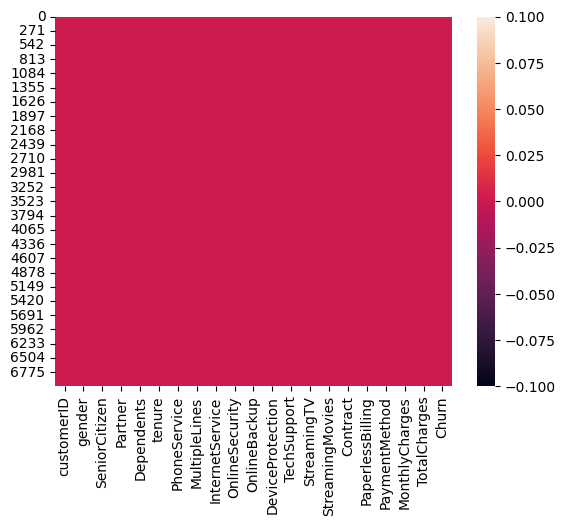

In [8]:
sns.heatmap(data = df.isnull(), cbar="False")

In [11]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df['tenure'] = pd.to_numeric(df.tenure, errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df[np.isnan(df['TotalCharges'])==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
df = df[df['tenure'] != 0].copy()

In [14]:
df.shape

(7032, 21)

In [15]:
df.nunique()


customerID          7032
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [16]:
df.drop(columns = ['customerID'], inplace = True)

In [17]:
def encode_yes_no(col, df2):
    df2[col] = df2[col].map({'Yes':1, 'No':0})
    

Text(0.5, 1.0, 'Customer Churn')

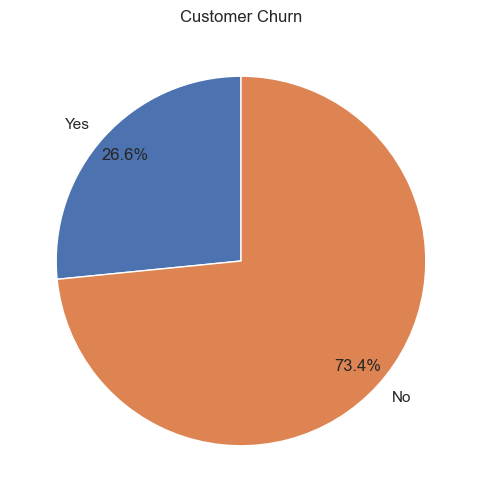

In [18]:

data = {
    "Churn": ["Yes", "No"],
    "Count": [df["Churn"].value_counts()["Yes"], df["Churn"].value_counts()["No"]]
}
churn_df = pd.DataFrame(data)

plt.figure(figsize=(6, 6))
sns.set_palette("pastel")
sns.set(style="whitegrid")

plt.pie(churn_df["Count"], labels=churn_df["Churn"], autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title("Customer Churn")

Text(0.5, 1.0, 'Feature Correlation Matrix')

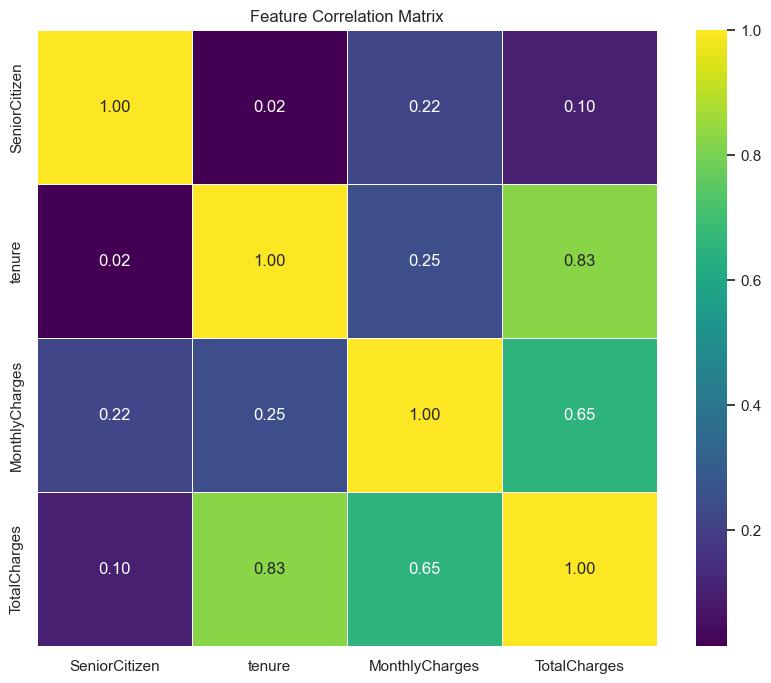

In [19]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(correlation, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5)

# Set the title
plt.title("Feature Correlation Matrix")

In [20]:
df["Churn"][df["Churn"]=="Yes"].groupby(by=df["SeniorCitizen"]).count()

SeniorCitizen
0    1393
1     476
Name: Churn, dtype: int64

In [21]:
df["Churn"][df["Churn"]=="No"].groupby(by=df["SeniorCitizen"]).count()

SeniorCitizen
0    4497
1     666
Name: Churn, dtype: int64

In [22]:
def get_size_list(df, col):
  a = df["Churn"][df["Churn"]=="Yes"].groupby(by=df[col]).count().iloc[1]
  b = df["Churn"][df["Churn"]=="Yes"].groupby(by=df[col]).count().iloc[0]
  c = df["Churn"][df["Churn"]=="No"].groupby(by=df[col]).count().iloc[1]
  d = df["Churn"][df["Churn"]=="No"].groupby(by=df[col]).count().iloc[0]
  l = [a, b, c, d]
  return l

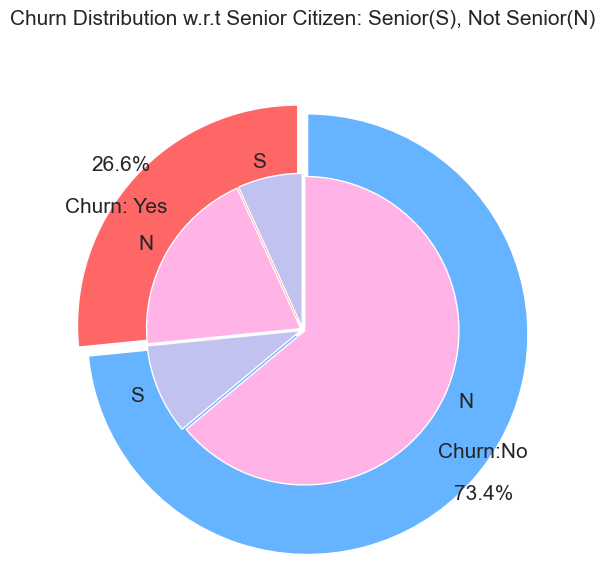

In [23]:
plt.figure(figsize=(6, 6))
labels =["Churn: Yes","Churn:No"]
values = [1869,5163]
labels_gender = ["S","N","S","N"]
sizes_gender = [476,1393,666,4497]
colors = ['#ff6666', '#66b3ff']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3)
explode_gender = (0.1,0.1,0.1,0.1)
textprops = {"fontsize":15}
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors, startangle=90,frame=True, explode=explode,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7, textprops =textprops, counterclock = True, )
#Draw circle
plt.title('Churn Distribution w.r.t Senior Citizen: Senior(S), Not Senior(N)', fontsize=15, y=1.1)

# show plot

plt.axis('equal')
plt.tight_layout()
plt.show()

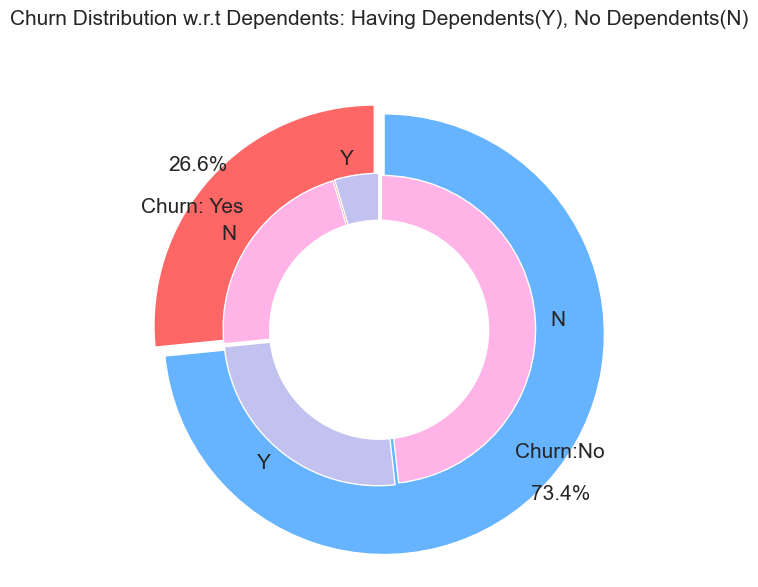

In [24]:
plt.figure(figsize=(6, 6))
labels =["Churn: Yes","Churn:No"]
values = [1869,5163]
labels_gender = ["Y","N","Y","N"]
sizes_gender = get_size_list(df, 'Dependents')
colors = ['#ff6666', '#66b3ff']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3)
explode_gender = (0.1,0.1,0.1,0.1)
textprops = {"fontsize":15}
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors, startangle=90,frame=True, explode=explode,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7, textprops =textprops, counterclock = True, )
#Draw circle
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Churn Distribution w.r.t Dependents: Having Dependents(Y), No Dependents(N)', fontsize=15, y=1.1)

# show plot

plt.axis('equal')
plt.tight_layout()
plt.show()

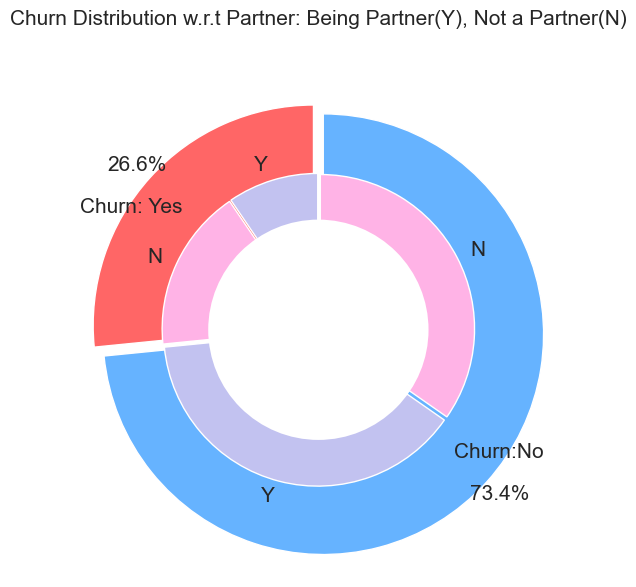

In [25]:
plt.figure(figsize=(6, 6))
labels =["Churn: Yes","Churn:No"]
values = [1869,5163]
labels_gender = ["Y","N","Y","N"]
sizes_gender = get_size_list(df, 'Partner')
colors = ['#ff6666', '#66b3ff']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3)
explode_gender = (0.1,0.1,0.1,0.1)
textprops = {"fontsize":15}
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors, startangle=90,frame=True, explode=explode,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7, textprops =textprops, counterclock = True, )
#Draw circle
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Churn Distribution w.r.t Partner: Being Partner(Y), Not a Partner(N)', fontsize=15, y=1.1)

# show plot

plt.axis('equal')
plt.tight_layout()
plt.show()

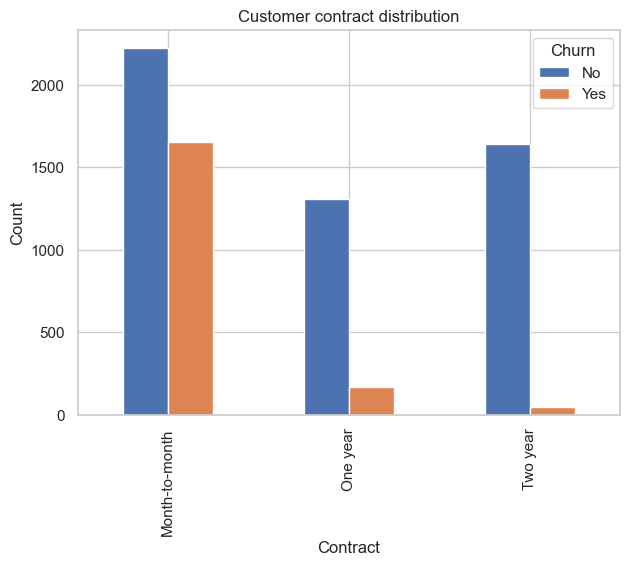

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))

# Group data by Contract and Churn
grouped_data = df.groupby(['Contract', 'Churn']).size().unstack()

# Plot the histogram
grouped_data.plot(kind='bar', stacked=False, ax=ax)
ax.set_xlabel('Contract')
ax.set_ylabel('Count')
ax.set_title('Customer contract distribution')
ax.legend(title='Churn')

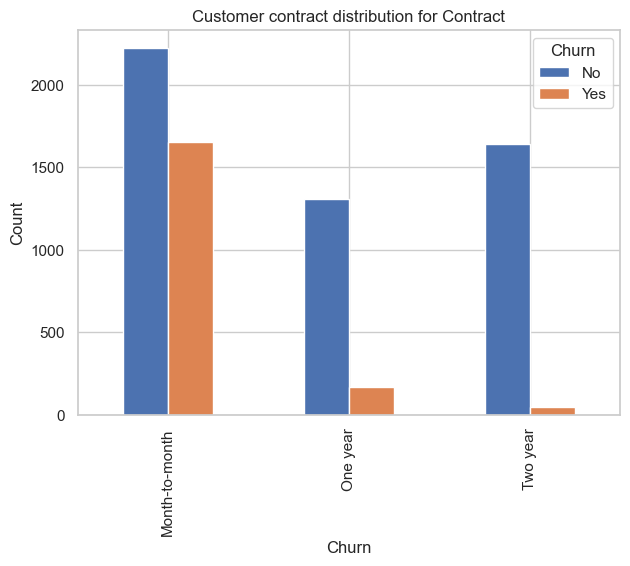

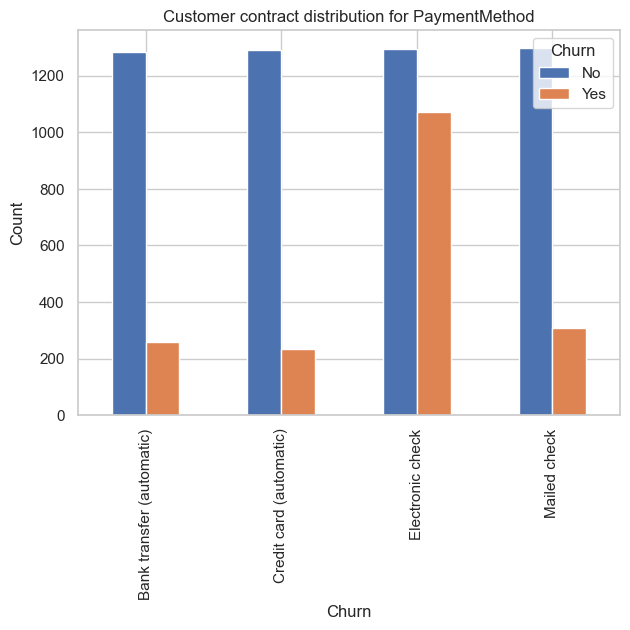

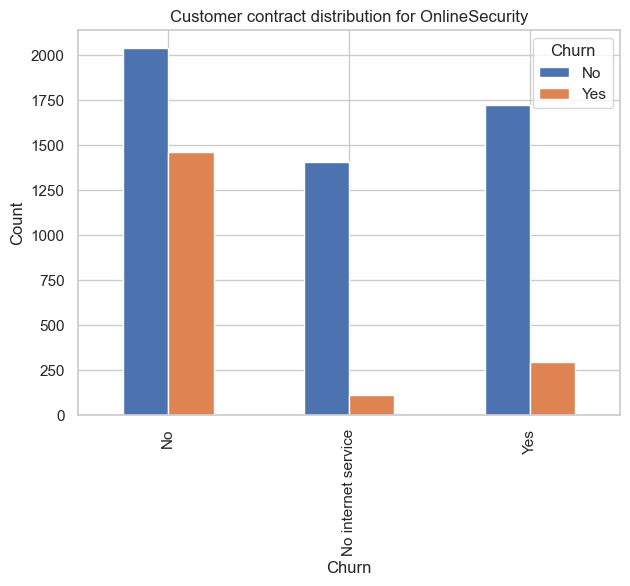

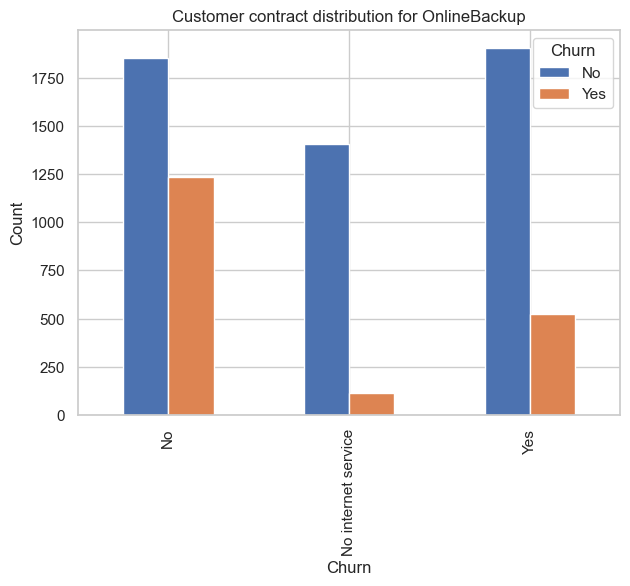

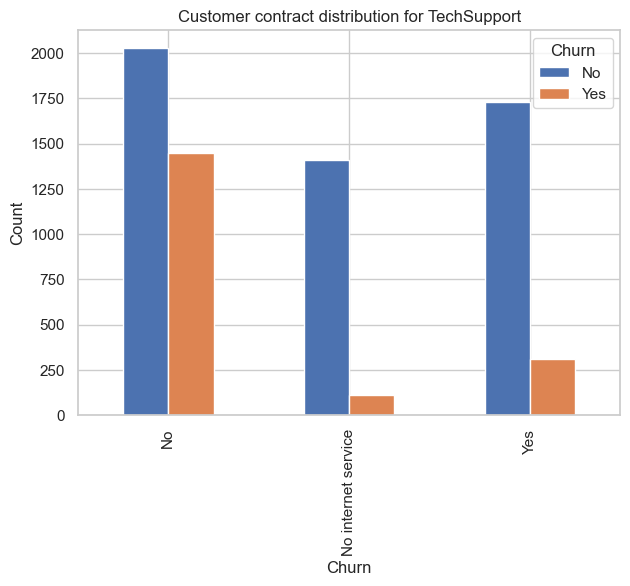

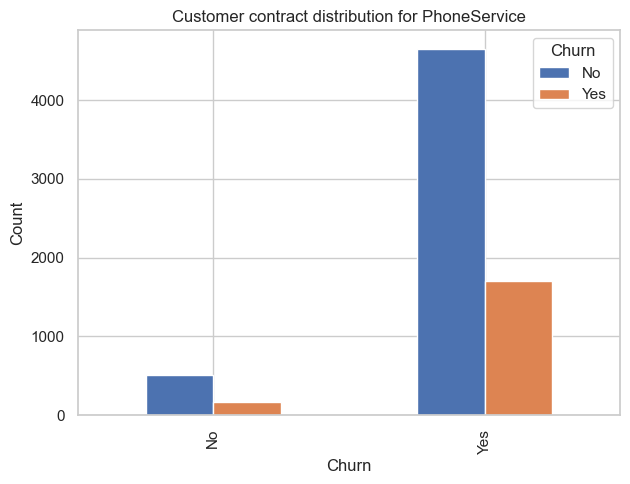

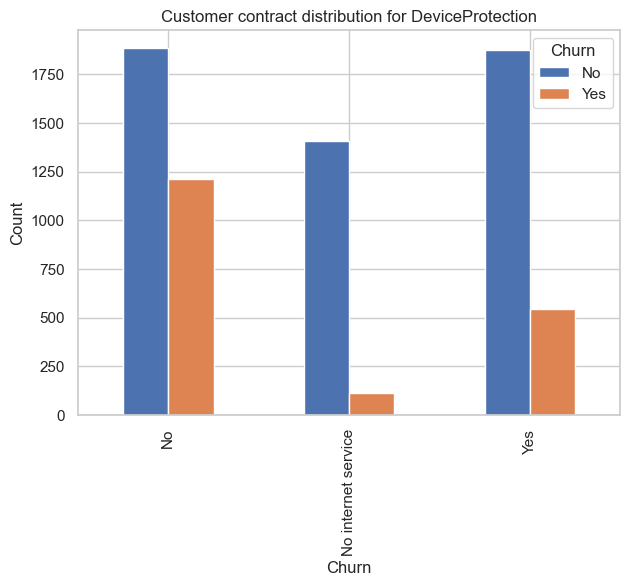

In [27]:
import matplotlib.pyplot as plt

# List of values to replace 'Contract' in each plot
contract_values = ['Contract', 'PaymentMethod', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'PhoneService', 'DeviceProtection']  # Replace with your values

# Create a subplot for each contract value
for contract_value in contract_values:
    fig, ax = plt.subplots(figsize=(7, 5))

    # Group data by Churn for the current contract value
    grouped_data = df.groupby([contract_value, 'Churn']).size().unstack()

    # Plot the histogram
    grouped_data.plot(kind='bar', stacked=False, ax=ax)
    ax.set_xlabel('Churn')
    ax.set_ylabel('Count')
    ax.set_title(f'Customer contract distribution for {contract_value}')
    ax.legend(title='Churn')

plt.show()  # Show all the plots


In [28]:
cols_to_encode = [col for col in df.columns if df[col].nunique() > 1 and df[col].nunique() < 5]

In [29]:
cols_to_encode

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [30]:
le = LabelEncoder()

for col in cols_to_encode:
  df[col] = le.fit_transform(df[col])

In [31]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [32]:
X = df.drop(columns = ['Churn'])
y = df['Churn'].values

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 76)

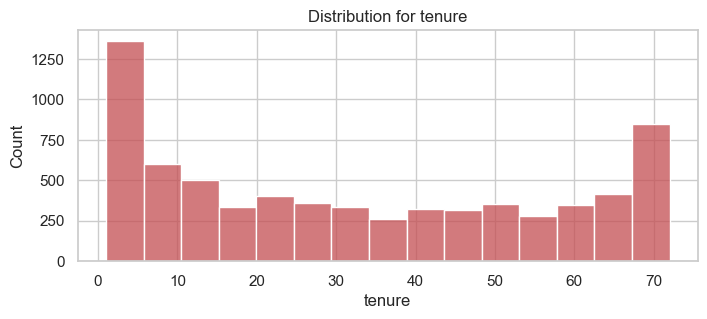

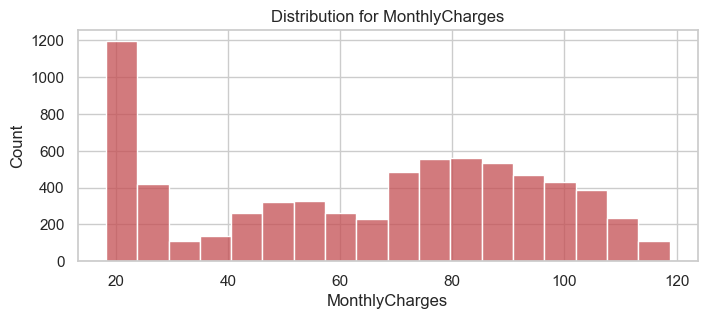

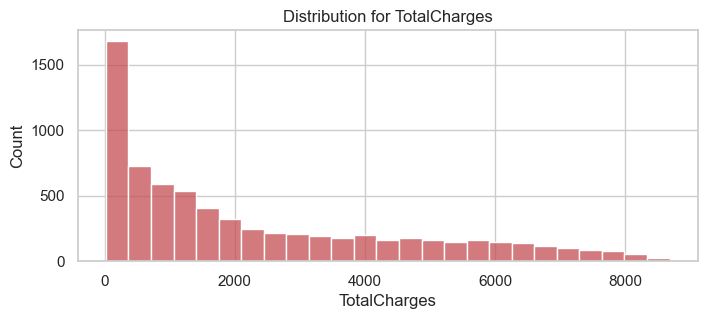

In [34]:
def distplot(feature, frame, color='r'):
    plt.figure(figsize=(8,3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.histplot(frame[feature], color= color)

num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

In [35]:
scaler= StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


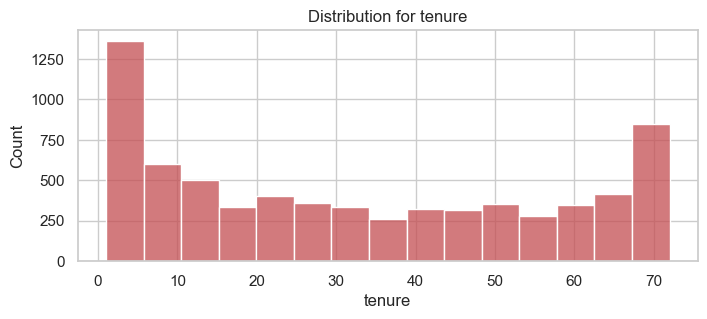

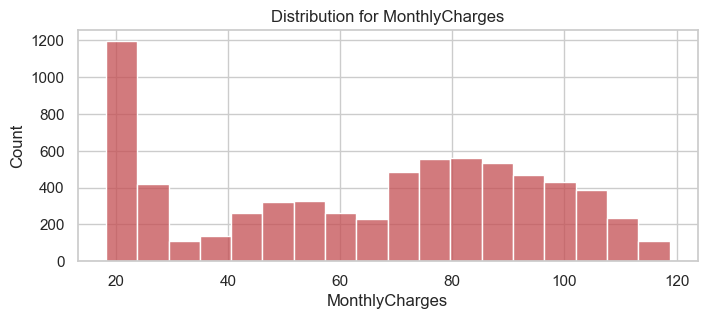

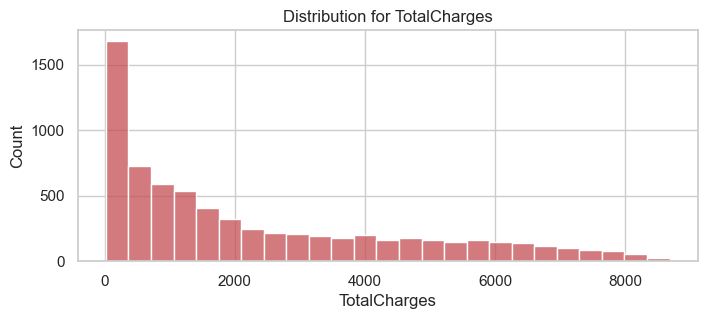

In [36]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

In [38]:
model_rf = RandomForestClassifier(n_estimators=100 , oob_score = True, n_jobs = -1,
                                  random_state =40, max_features = "sqrt",
                                  max_leaf_nodes = 60)
model_rf.fit(X_train, y_train)

# Make predictions
prediction_test = model_rf.predict(X_test)
print (metrics.accuracy_score(y_test, prediction_test))

0.795260663507109


In [39]:
print(classification_report(y_test, prediction_test))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1559
           1       0.64      0.48      0.55       551

    accuracy                           0.80      2110
   macro avg       0.74      0.69      0.71      2110
weighted avg       0.78      0.80      0.78      2110



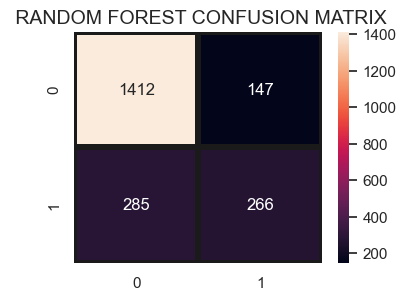

In [40]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, prediction_test),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title(" RANDOM FOREST CONFUSION MATRIX",fontsize=14)
plt.show()


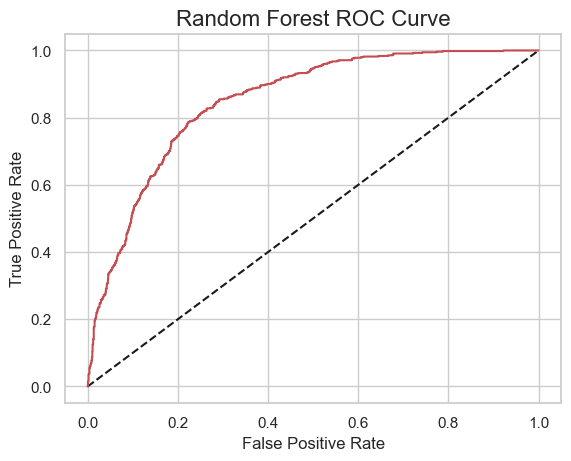

In [41]:
y_rfpred_prob = model_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_rfpred_prob, pos_label=1)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr_rf, tpr_rf, label='Random Forest',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve',fontsize=16)
plt.show();


In [42]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN Classifier accuracy:", metrics.accuracy_score(y_test, knn_pred))


KNN Classifier accuracy: 0.7663507109004739


In [43]:
print("KNN Classification Report")
print(classification_report(y_test, knn_pred))

KNN Classification Report
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1559
           1       0.55      0.54      0.55       551

    accuracy                           0.77      2110
   macro avg       0.70      0.69      0.70      2110
weighted avg       0.76      0.77      0.77      2110



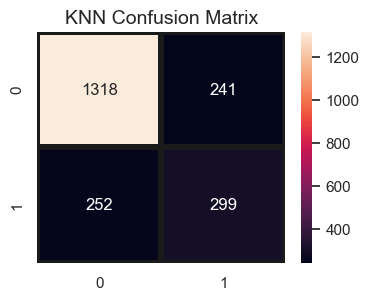

In [44]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt="d",
            linecolor="k", linewidths=3)
plt.title("KNN Confusion Matrix", fontsize=14)
plt.show()



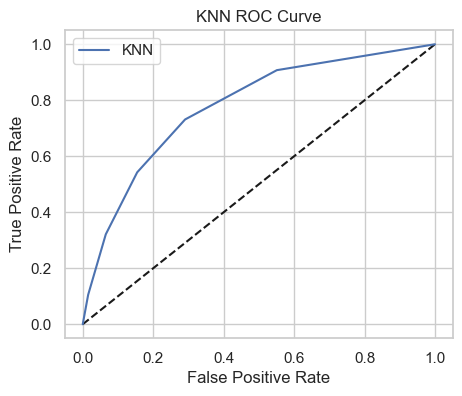

In [45]:
knn_prob = knn.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob, pos_label=1)
plt.figure(figsize=(5,4))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_knn, tpr_knn, label='KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')
plt.legend()
plt.show()



In [46]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Classifier accuracy:", metrics.accuracy_score(y_test, dt_pred))


Decision Tree Classifier accuracy: 0.7919431279620853


In [47]:
print("Decision Tree Classification Report")
print(classification_report(y_test, dt_pred))


Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1559
           1       0.63      0.49      0.55       551

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110



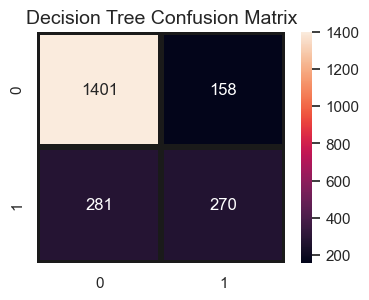

In [48]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt="d",
            linecolor="k", linewidths=3)
plt.title("Decision Tree Confusion Matrix", fontsize=14)
plt.show()


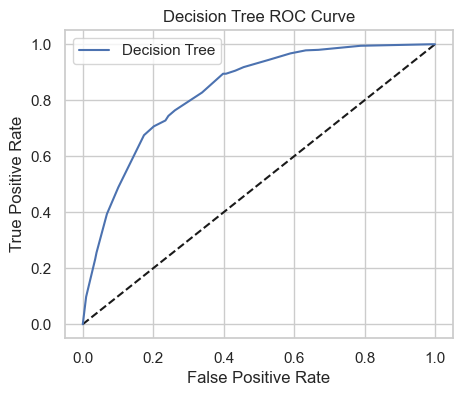

In [49]:
dt_prob = dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob, pos_label=1)
plt.figure(figsize=(5,4))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_dt, tpr_dt, label='Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend()
plt.show()


In [50]:
a_model = AdaBoostClassifier()
a_model.fit(X_train,y_train)
a_preds = a_model.predict(X_test)
print("AdaBoost Classifier accuracy")
metrics.accuracy_score(y_test, a_preds)


AdaBoost Classifier accuracy


0.7962085308056872

In [51]:
print(classification_report(y_test, a_preds))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1559
           1       0.63      0.54      0.58       551

    accuracy                           0.80      2110
   macro avg       0.74      0.71      0.72      2110
weighted avg       0.79      0.80      0.79      2110



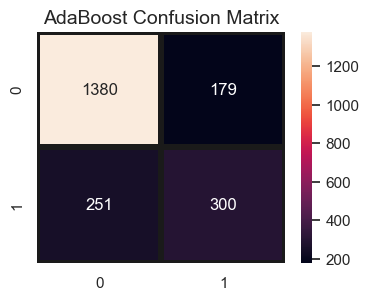

In [52]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, a_preds),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("AdaBoost Confusion Matrix",fontsize=14)
plt.show()

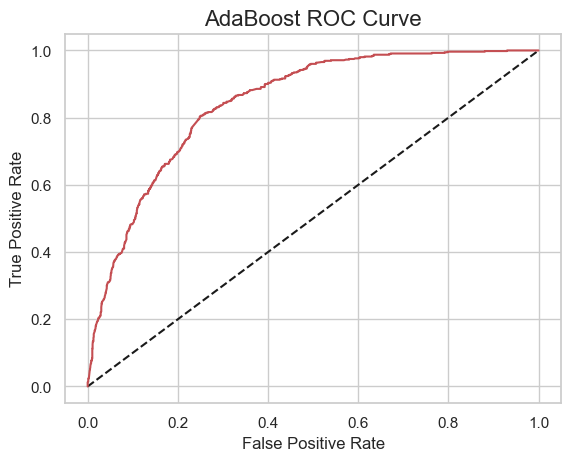

In [53]:
a_pred_prob = a_model.predict_proba(X_test)[:,1]
fpr_ab, tpr_ab, thresholds = roc_curve(y_test, a_pred_prob, pos_label=1)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr_ab, tpr_ab, label='AdaBoost',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AdaBoost ROC Curve',fontsize=16)
plt.show();

In [54]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print("Gradient Boosting Classifier", metrics.accuracy_score(y_test, gb_pred))

Gradient Boosting Classifier 0.7943127962085308


In [55]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1559
           1       0.63      0.51      0.56       551

    accuracy                           0.79      2110
   macro avg       0.73      0.70      0.71      2110
weighted avg       0.78      0.79      0.79      2110



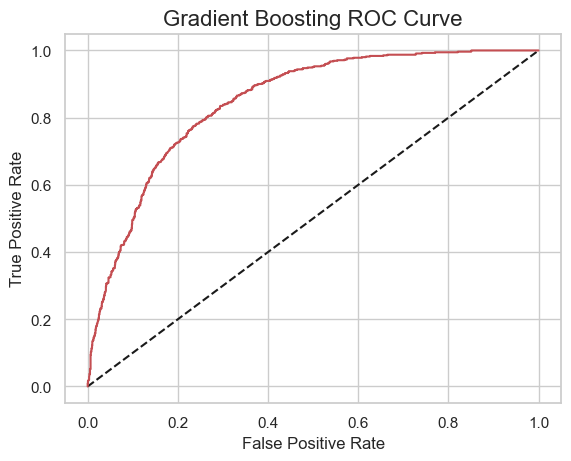

In [56]:
gb_pred_prob = gb.predict_proba(X_test)[:,1]
fpr_gb, tpr_gb, thresholds = roc_curve(y_test, gb_pred_prob, pos_label=1)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gradient Boosting ROC Curve',fontsize=16)
plt.show();

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "KNN": (knn, knn_pred),
    "Decision Tree": (dt, dt_pred),
    "Random Forest": (model_rf, prediction_test),
    "AdaBoost": (a_model, a_preds),
    "Gradient Boosting": (gb, gb_pred)
}

results = []
for name, (model, predictions) in models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, pos_label=1),
        "Recall": recall_score(y_test, predictions, pos_label=1),
        "F1-Score": f1_score(y_test, predictions, pos_label=1),
        "ROC-AUC": roc_auc_score((y_test == 1).astype(int), probabilities)
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,AdaBoost,0.796209,0.626305,0.544465,0.582524,0.844446
4,Gradient Boosting,0.794313,0.632054,0.508167,0.563380,0.847142
2,Random Forest,0.795261,0.644068,0.482759,0.551867,0.849846
1,Decision Tree,0.791943,0.630841,0.490018,0.551583,0.832129
0,KNN,0.766351,0.553704,0.542650,0.548121,0.778239
